# Imports

In [134]:
# %matplotlib inline
import os, re, importlib.util
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.stats import skew, kurtosis
from astropy.table import Table

# Parsing

## Input file

In [135]:
# Binary file to be analyzed
INPUT_FILE = "/Users/evanwilliams/Desktop/asio-analyze/data/20260608.0x02B4"

## Packet layout & constants (ICD)

**ICD §5.1** — Packet size: **950 bytes**, little-endian.

**Table 10 — header layout** (44 bytes before ADC data):

| Bytes      | Field                                                        |
| ---------- | ------------------------------------------------------------ |
| `[0:4]`    | Start ID `"ASIO"`                                            |
| `[4]`      | Relay configuration (1 byte)                                 |
| `[5:15]`   | Temperature data (5 sensors × 2 bytes, 16-bit LE)            |
| `[15]`     | Bad command count (1 byte)                                   |
| `[16]`     | Padded zero (1 byte)                                         |
| `[17:19]`  | Voltage data (2 bytes, 16-bit LE)                            |
| `[19:21]`  | Current data (2 bytes, 16-bit LE)                            |
| `[21:23]`  | Packet count (2 bytes, 16-bit LE)                            |
| `[23]`     | Command count (1 byte)                                       |
| `[24:30]`  | MUSE time (4 bytes seconds + 2 bytes sub-seconds, LE)        |
| `[30:32]`  | Padded zeros (2 bytes)                                       |
| `[32:36]`  | ASIO time ms (4 bytes, 32-bit LE)                            |
| `[36:40]`  | First data point ASIO time ms (4 bytes, 32-bit LE)           |
| `[40:44]`  | Padded zeros (4 bytes)                                       |
| `[44:944]` | ADC data (900 bytes = 50 segments × 18 bytes)                |
| `[944:948]`| End ID `"STOP"`                                              |
| `[948:950]`| CRC (2 bytes)                                                |

In [136]:
PACKET_SIZE       = 950
HEADER_SIZE       = 44
ADC_SEGMENT_BYTES = 18   # 6 channels x 3 bytes each
N_SEGMENTS        = 50   # per packet
ADC_DATA_SIZE     = N_SEGMENTS * ADC_SEGMENT_BYTES  # 900 bytes
STOP_OFFSET       = HEADER_SIZE + ADC_DATA_SIZE     # 944

# ICD Table 12: relay byte bit layout LSB->MSB.
# EUV5/6/7 gate the EUV channel; HXR8/9/10/11 gate the HXR channel.
RELAY_BITS = {
    'EUV5':  0,
    'EUV6':  1,
    'EUV7':  2,
    'HXR8':  3,
    'HXR9':  4,
    'HXR10': 5,
    'HXR11': 6,
}

# Which ADC channel each relay affects (used by the plot below).
CHANNEL_RELAYS = {
    'HXR':  ['HXR8', 'HXR9', 'HXR10', 'HXR11'],
    'EUV':  ['EUV5', 'EUV6', 'EUV7'],
    'SXR1': [],
    'SXR2': [],
    'SXR3': [],
    'SXR4': [],
}

## Decode helpers

In [137]:
def find(targetString, data):
    targetBytes = targetString.encode()
    targetIntegers = np.frombuffer(targetBytes, dtype=np.uint8)
    windows = sliding_window_view(data, len(targetIntegers))
    matches = (windows == targetIntegers).all(axis=1)
    return np.where(matches)[0]


def decode16le(b2):
    """2 bytes -> unsigned 16-bit little-endian integer."""
    return int(b2[0]) | (int(b2[1]) << 8)


def decode24le(b3):
    """3 bytes -> unsigned 24-bit little-endian integer (ICD §5.1.3, Table 13)."""
    return int(b3[0]) | (int(b3[1]) << 8) | (int(b3[2]) << 16)


def decode32le(b4):
    """4 bytes -> unsigned 32-bit little-endian integer."""
    return int(b4[0]) | (int(b4[1]) << 8) | (int(b4[2]) << 16) | (int(b4[3]) << 24)

## Parse packets

In [138]:
rawdata = np.fromfile(
    INPUT_FILE,
    dtype=np.uint8,
)

# Build packet list using fixed offsets (ICD §5.1.2: 950-byte fixed packet) 
# Searching for STOP at asioIndex + STOP_OFFSET is far more robust than pairing
# find("STOP") results, which breaks if "STOP" appears by coincidence inside ADC data.
asioMatches = find("ASIO", rawdata)

packetList = []
bad_packets = 0
for asioIndex in asioMatches:
    end = asioIndex + PACKET_SIZE
    if end > len(rawdata):
        bad_packets += 1
        continue
    stop_check = rawdata[asioIndex + STOP_OFFSET : asioIndex + STOP_OFFSET + 4].tobytes()
    if stop_check != b'STOP':
        bad_packets += 1
        continue
    packetList.append(rawdata[asioIndex:end])

print(f"Valid packets: {len(packetList)}  |  Rejected: {bad_packets}")

Valid packets: 142350  |  Rejected: 2


## Header & relay decoding

In [139]:
# Extract relay config, flip events, and all header housekeeping fields
def parseHeader(packet):
    """Return a dict of all header fields for one packet."""
    relay = int(packet[4])

    temps_raw     = [decode16le(packet[5 + i*2 : 7 + i*2]) for i in range(5)]
    bad_cmd_count = int(packet[15])
    voltage_raw   = decode16le(packet[17:19])
    current_raw   = decode16le(packet[19:21])
    packet_count  = decode16le(packet[21:23])
    cmd_count     = int(packet[23])

    # MUSE time: 4 bytes seconds + 2 bytes sub-seconds (LE, epoch = 1958-01-01)
    muse_sec    = decode32le(packet[24:28])
    muse_subsec = decode16le(packet[28:30])

    asio_time_ms     = decode32le(packet[32:36])
    first_dp_asio_ms = decode32le(packet[36:40])

    return {
        'relay':          relay,
        'temps_raw':      temps_raw,
        'bad_cmd_count':  bad_cmd_count,
        'voltage_raw':    voltage_raw,
        'current_raw':    current_raw,
        'packet_count':   packet_count,
        'cmd_count':      cmd_count,
        'muse_sec':       muse_sec,
        'muse_subsec':    muse_subsec,
        'asio_time_ms':   asio_time_ms,
        'first_dp_ms':    first_dp_asio_ms,
    }


def getRelayConfig(packetList):
    """Decode every relay's per-packet ON/OFF state and its flip events.

    Returns:
        relayConfigs : list[int]                     raw relay byte per packet
        states       : dict[name -> list[bool]]      per-packet state per relay
        flips        : dict[name -> list[dict]]      transition events per relay
    """
    relayConfigs = []
    states = {name: [] for name in RELAY_BITS}
    flips  = {name: [] for name in RELAY_BITS}
    prev   = {name: None for name in RELAY_BITS}

    for idx, packet in enumerate(packetList):
        relayByte = int(packet[4])
        relayConfigs.append(relayByte)

        for name, bit in RELAY_BITS.items():
            state = bool((relayByte >> bit) & 0x01)
            states[name].append(state)

            if prev[name] is not None and state != prev[name]:
                direction = "OFF->ON" if state else "ON->OFF"
                flips[name].append({
                    'packet': idx,
                    'relay_byte': relayByte,
                    'direction': direction,
                    'state': state,
                })
            prev[name] = state

    return relayConfigs, states, flips

## Decode ADC data

In [140]:
# ----- Parse ADC data: each channel is 3 bytes decoded as a 24-bit LE integer -----
def getData(packetList):
    _, states, flips = getRelayConfig(packetList)
    for name in RELAY_BITS:
        print(f"{name:6s} states: {len(states[name]):5d}  |  flips: {len(flips[name])}")

    SXR1, SXR2, SXR3, SXR4, HXR, EUV = [], [], [], [], [], []
    headers = []

    for packet in packetList:
        headers.append(parseHeader(packet))

        adc_bytes = packet[HEADER_SIZE : HEADER_SIZE + ADC_DATA_SIZE]
        if len(adc_bytes) != ADC_DATA_SIZE:
            raise ValueError(f"Unexpected ADC data length: {len(adc_bytes)}")

        # 50 segments of 18 bytes each; each channel = 3 bytes -> 24-bit LE integer
        for seg_start in range(0, ADC_DATA_SIZE, ADC_SEGMENT_BYTES):
            seg = adc_bytes[seg_start : seg_start + ADC_SEGMENT_BYTES]
            SXR1.append(decode24le(seg[0:3]))
            SXR2.append(decode24le(seg[3:6]))
            SXR3.append(decode24le(seg[6:9]))
            SXR4.append(decode24le(seg[9:12]))
            HXR.append( decode24le(seg[12:15]))
            EUV.append( decode24le(seg[15:18]))

    return {
        'SXR1':        np.array(SXR1, dtype=np.uint32),
        'SXR2':        np.array(SXR2, dtype=np.uint32),
        'SXR3':        np.array(SXR3, dtype=np.uint32),
        'SXR4':        np.array(SXR4, dtype=np.uint32),
        'HXR':         np.array(HXR,  dtype=np.uint32),
        'EUV':         np.array(EUV,  dtype=np.uint32),
        'relayStates': {name: np.array(states[name], dtype=bool) for name in RELAY_BITS},
        'relayFlips':  flips,
        'headers':     headers,
    }


data = getData(packetList)

n_packets = len(packetList)
n_segments_total = n_packets * N_SEGMENTS
for key, val in data.items():
    if key not in ('relayStates', 'relayFlips', 'headers'):
        print(f"  {key}: {len(val)}")
print(f"  Expected ADC length: {n_segments_total}  (={n_packets} packets × {N_SEGMENTS} segments)")

EUV5   states: 142350  |  flips: 8
EUV6   states: 142350  |  flips: 8
EUV7   states: 142350  |  flips: 8
HXR8   states: 142350  |  flips: 8
HXR9   states: 142350  |  flips: 8
HXR10  states: 142350  |  flips: 8
HXR11  states: 142350  |  flips: 10
  SXR1: 7117500
  SXR2: 7117500
  SXR3: 7117500
  SXR4: 7117500
  HXR: 7117500
  EUV: 7117500
  Expected ADC length: 7117500  (=142350 packets × 50 segments)


## ADC counts -> volts

In [141]:
# Convert raw 24-bit ADC counts to volts (range [0, 5) V)
# around a 2.5 V midpoint with +/- 2.5 V full scale. Upper half (val > 0x7FFFFF)
# wraps to the negative side. Applied here so every downstream cell (segment
# selection, raw plot, detrending, EMI removal, cleaned plot) operates in volts
def ADC_to_V(val):
    arr  = np.asarray(val).astype(np.float64)
    high = arr > 0x7FFFFF
    pos  =  arr                   / 0x800000 * 2.5 + 2.5
    neg  = (arr - (0xFFFFFF + 1)) / 0x800000 * 2.5 + 2.5
    return np.where(high, neg, pos)

for _ch in ('SXR1', 'SXR2', 'SXR3', 'SXR4', 'HXR', 'EUV'):
    data[_ch] = ADC_to_V(data[_ch])
    print(f"{_ch:4s}  V range: [{data[_ch].min():.4f}, {data[_ch].max():.4f}]   "
          f"mean: {data[_ch].mean():.4f}")

SXR1  V range: [0.0058, 0.0059]   mean: 0.0059
SXR2  V range: [0.0061, 0.0061]   mean: 0.0061
SXR3  V range: [0.0000, 0.0125]   mean: 0.0062
SXR4  V range: [0.0059, 0.0060]   mean: 0.0059
HXR   V range: [0.0060, 0.0097]   mean: 0.0061
EUV   V range: [0.0058, 0.0059]   mean: 0.0059


## Segment selection

In [142]:
# AUTO SEGMENT SELECTION from .rpt files
# Scans data/RPTs/, pairs start/end reports by wall-clock,
# resolves each pair to a [start_packet, end_packet) range in
# the current binary, and lists them so you can pick one with
# SEGMENT_INDEX below. The manual cell that follows uses the
# values set here; set SEGMENT_INDEX = None to fall through to
# the manual values in the next cell.

_RPT_PATH = "/Users/evanwilliams/Desktop/asio-analyze/asio_analyze/rpt.py"
_spec = importlib.util.spec_from_file_location("_asio_rpt", _RPT_PATH)
_rpt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_rpt)

RPT_DIR = "/Users/evanwilliams/Desktop/asio-analyze/data/RPTs"

_bin_date = re.search(r"(\d{8})", os.path.basename(INPUT_FILE)).group(1)
_rpt_paths = sorted(
    os.path.join(RPT_DIR, f)
    for f in os.listdir(RPT_DIR)
    if f.endswith(".rpt") and f.startswith(_bin_date + "_")
)

_TEST_RE = re.compile(r"Test:\s*(\S+)")
def _label_for_start(path):
    with open(path) as f:
        for line in f:
            m = _TEST_RE.search(line)
            if m:
                return m.group(1)
    return os.path.basename(path)


def _resolve_pair_to_packets(headers, pair):
    """Return (start_pkt, end_pkt_exclusive) for one start/end .rpt pair.

    Mirrors the muse_sec window + asio_time argmin from asio_analyze.rpt;
    returns packet indices instead of sample-time.
    """
    s, e = pair["start"], pair["end"]
    muse_sec = np.array([h["muse_sec"] for h in headers], dtype=np.int64)
    asio_ms  = np.array([h["asio_time_ms"] for h in headers], dtype=np.int64)

    in_window = (muse_sec >= s["muse_sec"]) & (muse_sec <= e["muse_sec"])
    cand = np.where(in_window)[0]
    if cand.size == 0:
        raise ValueError(
            f"no packets in MUSE window [{s['muse_sec']}, {e['muse_sec']}]"
        )
    cand_asio = asio_ms[cand]
    start_pkt = int(cand[np.argmin(np.abs(cand_asio - s["asio_time_ms"]))])
    end_pkt   = int(cand[np.argmin(np.abs(cand_asio - e["asio_time_ms"]))])
    return start_pkt, end_pkt + 1


pairs, pair_errors = _rpt.pair_rpts(_rpt_paths)

available = []
for pair in pairs:
    try:
        sp, ep = _resolve_pair_to_packets(data["headers"], pair)
    except ValueError as err:
        print(f"skip pair {pair['start']['name']} -> {pair['end']['name']}: {err}")
        continue
    available.append({
        "label":     _label_for_start(pair["start"]["path"]),
        "start_pkt": sp,
        "end_pkt":   ep,
        "start_rpt": pair["start"]["name"],
        "end_rpt":   pair["end"]["name"],
    })

print(f"Found {len(available)} segment(s) for {os.path.basename(INPUT_FILE)}:")
for i, s in enumerate(available):
    print(f"  [{i}] {s['label']:>15s}  packets [{s['start_pkt']}, {s['end_pkt']})"
          f"   ({s['end_pkt'] - s['start_pkt']} pkts)")
    print(f"        {s['start_rpt']}  ->  {s['end_rpt']}")
for err in pair_errors:
    print(f"  ! pairing error: {os.path.basename(err['path'])}: {err['reason']}")

# ---- USER PICK ----
SEGMENT_INDEX = None   # set to None to use the manual values in the next cell

if SEGMENT_INDEX is not None and available:
    _sel = available[SEGMENT_INDEX]
    SEGMENT_START_PACKET = _sel["start_pkt"]
    SEGMENT_END_PACKET   = _sel["end_pkt"]
    SEGMENT_LABEL        = _sel["label"]
    print(f"\n-> selected [{SEGMENT_INDEX}] {SEGMENT_LABEL}: "
          f"packets [{SEGMENT_START_PACKET}, {SEGMENT_END_PACKET})")
else:
    SEGMENT_LABEL = None
    print("\n-> no auto selection; manual cell below will set the range.")

Found 8 segment(s) for 20260608.0x02B4:
  [0]       Relay11_1  packets [114199, 114847)   (648 pkts)
        20260608_180653_asio_start_test.rpt  ->  20260608_181219_asio_end_test.rpt
  [1]    Background_1  packets [140215, 140592)   (377 pkts)
        20260608_214340_asio_start_test.rpt  ->  20260608_214648_asio_end_test.rpt
  [2]    RelayFlips_1  packets [140621, 140916)   (295 pkts)
        20260608_214703_asio_start_test.rpt  ->  20260608_214930_asio_end_test.rpt
  [3] FlipRelaysAll_1  packets [141061, 141301)   (240 pkts)
        20260608_215042_asio_start_test.rpt  ->  20260608_215243_asio_end_test.rpt
  [4]          NOOP_1  packets [141332, 141363)   (31 pkts)
        20260608_215259_asio_start_test.rpt  ->  20260608_215314_asio_end_test.rpt
  [5]           ADC_1  packets [141390, 141533)   (143 pkts)
        20260608_215327_asio_start_test.rpt  ->  20260608_215439_asio_end_test.rpt
  [6]    PowerCycle_1  packets [141568, 141774)   (206 pkts)
        20260608_215457_asio_start_t

In [143]:
# ============================================================
# SEGMENT SELECTION -- analyze/display only a slice of the data.
# Range is given in PACKETS; defaults span the entire capture.
# Each packet contains N_SEGMENTS (50) ADC samples per channel.
#
# If the auto-selection cell above set SEGMENT_START_PACKET /
# SEGMENT_END_PACKET, those values are kept. Otherwise this cell
# falls back to the full capture. To force a manual range, set
# SEGMENT_INDEX = None in the cell above and edit the two
# fallbacks below.
# ============================================================
try:
    SEGMENT_START_PACKET
except NameError:
    SEGMENT_START_PACKET = 0
try:
    SEGMENT_END_PACKET
except NameError:
    SEGMENT_END_PACKET = len(packetList)   # exclusive


def selectSegment(data, start_packet, end_packet):
    """Slice the parsed `data` dict down to packets [start_packet, end_packet).

    ADC channels are sliced at sample resolution (packet * N_SEGMENTS); relay
    states are sliced per packet; relay flips are filtered to the window and
    re-indexed so that packet 0 is the start of the selected segment.
    """
    s = start_packet * N_SEGMENTS
    e = end_packet * N_SEGMENTS

    channel_keys = ('SXR1', 'SXR2', 'SXR3', 'SXR4', 'HXR', 'EUV')
    seg = {key: data[key][s:e] for key in channel_keys}

    seg['relayStates'] = {
        name: data['relayStates'][name][start_packet:end_packet]
        for name in RELAY_BITS
    }
    seg['relayFlips'] = {
        name: [
            {**f, 'packet': f['packet'] - start_packet}
            for f in data['relayFlips'][name]
            if start_packet <= f['packet'] < end_packet
        ]
        for name in RELAY_BITS
    }
    seg['headers'] = data['headers'][start_packet:end_packet]
    return seg


segment = selectSegment(data, SEGMENT_START_PACKET, SEGMENT_END_PACKET)
print(f"Segment: packets [{SEGMENT_START_PACKET}, {SEGMENT_END_PACKET})  "
      f"-> {len(segment['SXR1'])} samples per channel")

Segment: packets [114199, 114847)  -> 32400 samples per channel


## Display: channels over relay states

/var/folders/sf/d8nsgnln2vl_f0yxy8t_5sx00000gn/T/ipykernel_41148/2127683399.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


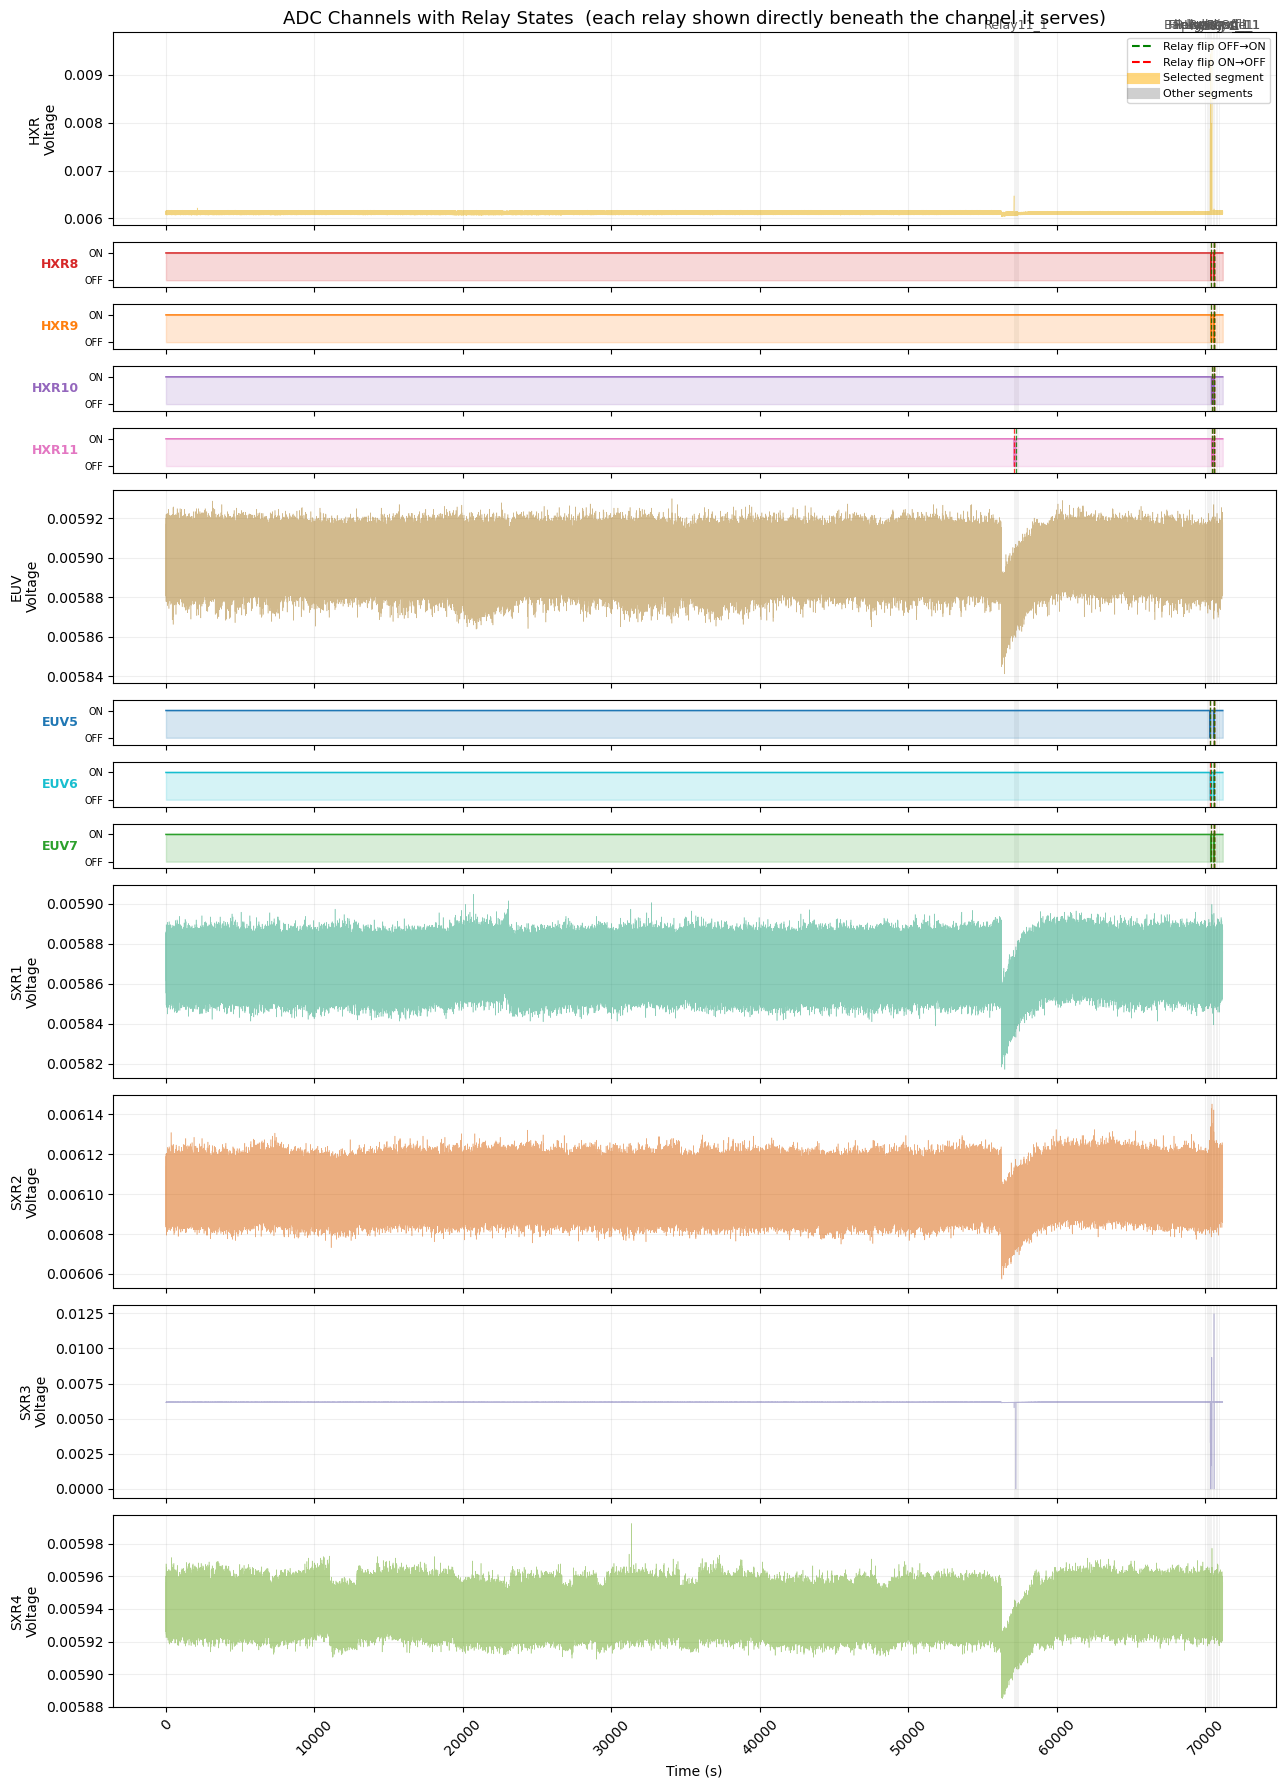

EUV5   flips (8):
    packet 140658  sample ~7032900  ON->OFF
    packet 140673  sample ~7033650  OFF->ON
    packet 141118  sample ~7055900  ON->OFF
    packet 141122  sample ~7056100  OFF->ON
    packet 141126  sample ~7056300  ON->OFF
    packet 141173  sample ~7058650  OFF->ON
    packet 141177  sample ~7058850  ON->OFF
    packet 141183  sample ~7059150  OFF->ON
EUV6   flips (8):
    packet 140693  sample ~7034650  ON->OFF
    packet 140710  sample ~7035500  OFF->ON
    packet 141118  sample ~7055900  ON->OFF
    packet 141129  sample ~7056450  OFF->ON
    packet 141133  sample ~7056650  ON->OFF
    packet 141173  sample ~7058650  OFF->ON
    packet 141177  sample ~7058850  ON->OFF
    packet 141183  sample ~7059150  OFF->ON
EUV7   flips (8):
    packet 140729  sample ~7036450  ON->OFF
    packet 140747  sample ~7037350  OFF->ON
    packet 141118  sample ~7055900  ON->OFF
    packet 141135  sample ~7056750  OFF->ON
    packet 141138  sample ~7056900  ON->OFF
    packet 141173  sam

In [144]:
# ----- ADC channel timeseries -----
# This plot shows the FULL raw capture with every detected segment overlaid as
# a translucent axvspan so you can see where each test sits in the whole stream.
# Downstream analysis cells still operate on the sliced `segment` dict.
channels = {
    'HXR':  data['HXR'].astype(float),
    'EUV':  data['EUV'].astype(float),
    'SXR1': data['SXR1'].astype(float),
    'SXR2': data['SXR2'].astype(float),
    'SXR3': data['SXR3'].astype(float),
    'SXR4': data['SXR4'].astype(float),
}
CHANNEL_ORDER = ['HXR', 'EUV', 'SXR1', 'SXR2', 'SXR3', 'SXR4']

# Relay states/flips for the full capture (not the slice).
relayStates = data['relayStates']
relayFlips  = data['relayFlips']

# Distinct color per relay so each state trace is easy to tell apart.
RELAY_COLORS = {
    'EUV5':  '#1f77b4',  # blue
    'EUV6':  '#17becf',  # cyan
    'EUV7':  '#2ca02c',  # green
    'HXR8':  '#d62728',  # red
    'HXR9':  '#ff7f0e',  # orange
    'HXR10': '#9467bd',  # purple
    'HXR11': '#e377c2',  # pink
}

# Per-channel colors matched to the asio-analyze report style ('Dark2' colormap,
# indexed in the same order as channel_names in noise_analysis.py).
CHANNEL_CMAP   = plt.get_cmap('Dark2')
CHANNEL_NAMES_REPORT_ORDER = ['SXR1', 'SXR2', 'SXR3', 'SXR4', 'HXR', 'EUV']
CHANNEL_COLORS = {
    name: CHANNEL_CMAP(i / len(CHANNEL_NAMES_REPORT_ORDER))
    for i, name in enumerate(CHANNEL_NAMES_REPORT_ORDER)
}

# Each packet = N_SEGMENTS (50) decoded samples; repeat state 50x to share x-axis.
SAMPLES_PER_PACKET = N_SEGMENTS

# ASIO sampling cadence is 100 Hz (matches asio_analyze/noise_analysis.py);
# convert sample index -> seconds so axes match the asio-analyze report style.
SAMPLING_RATE = 100
DT            = 1.0 / SAMPLING_RATE
time_s        = np.arange(len(channels['HXR'])) * DT

# Resolve segment windows from `available` (set by the auto-selection cell) into
# (label, t_start, t_end) tuples. Falls back to empty list if the auto cell
# wasn't run, in which case nothing is highlighted.
try:
    _available = available
except NameError:
    _available = []
SEGMENT_SPANS = [
    (s["label"],
     s["start_pkt"] * SAMPLES_PER_PACKET * DT,
     s["end_pkt"]   * SAMPLES_PER_PACKET * DT)
    for s in _available
]
# Highlight the user-picked segment more strongly than the rest.
try:
    _sel_idx = SEGMENT_INDEX
except NameError:
    _sel_idx = None

# ----- Build the row layout: each channel, followed by its relay-state panels -----
rows = []  # list of ('channel'|'relay', name)
for ch in CHANNEL_ORDER:
    rows.append(('channel', ch))
    for relay in CHANNEL_RELAYS[ch]:
        rows.append(('relay', relay))

# Channel panels tall, relay panels short.
height_ratios = [3.0 if kind == 'channel' else 0.7 for kind, _ in rows]

fig, axes = plt.subplots(
    len(rows), 1,
    figsize=(15, 0.95 * sum(height_ratios)),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.15},
)

axes[0].set_title(
    'ADC Channels with Relay States  (each relay shown directly beneath the channel it serves)',
    fontsize=13,
)

for ax, (kind, name) in zip(axes, rows):
    if kind == 'channel':
        ax.plot(time_s, channels[name],
                linewidth=0.4, color=CHANNEL_COLORS[name], alpha=0.5)
        ax.set_ylabel(f'{name}\nVoltage', fontsize=10)
        ax.tick_params(axis='x', labelrotation=45)
        ax.grid(True, alpha=0.2)
    else:  # relay state panel
        color = RELAY_COLORS[name]
        expanded = np.repeat(relayStates[name], SAMPLES_PER_PACKET).astype(float)
        x = np.arange(len(expanded)) * DT
        ax.plot(x, expanded, linewidth=1.1, color=color, drawstyle='steps-post')
        ax.fill_between(x, expanded, step='post', color=color, alpha=0.18)
        ax.set_ylabel(name, color=color, fontweight='bold', fontsize=9, rotation=0,
                      ha='right', va='center')
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['OFF', 'ON'], fontsize=7)
        ax.set_ylim(-0.25, 1.4)

        # Mark this relay's flip events (green = turns ON, red = turns OFF).
        for f in relayFlips[name]:
            pos = f['packet'] * SAMPLES_PER_PACKET * DT
            fc = 'green' if f['direction'].endswith('ON') else 'red'
            ax.axvline(pos, color=fc, linestyle='--', linewidth=0.9, alpha=0.8)

    # Overlay every detected segment as a translucent axvspan; selected one is
    # darker. Label only on the top channel panel so the legend stays clean.
    for i, (label, t0, t1) in enumerate(SEGMENT_SPANS):
        is_selected = (i == _sel_idx)
        ax.axvspan(
            t0, t1,
            color='#ffb000' if is_selected else '#888888',
            alpha=0.22 if is_selected else 0.10,
            linewidth=0,
            zorder=0,
        )

# Segment name labels along the top of the first channel panel.
top_ax = axes[0]
ymin, ymax = top_ax.get_ylim()
for i, (label, t0, t1) in enumerate(SEGMENT_SPANS):
    is_selected = (i == _sel_idx)
    top_ax.text(
        0.5 * (t0 + t1), ymax,
        label + ('  ◄ selected' if is_selected else ''),
        ha='center', va='bottom', fontsize=9,
        fontweight='bold' if is_selected else 'normal',
        color='#b07000' if is_selected else '#555555',
        clip_on=False,
    )

axes[-1].set_xlabel('Time (s)', fontsize=10)

# Flip-direction legend.
legend_elements = [
    Line2D([0], [0], color='green', linestyle='--', label='Relay flip OFF→ON'),
    Line2D([0], [0], color='red',   linestyle='--', label='Relay flip ON→OFF'),
]
if SEGMENT_SPANS:
    legend_elements.append(
        Line2D([0], [0], color='#ffb000', linewidth=8, alpha=0.5,
               label='Selected segment')
    )
    if len(SEGMENT_SPANS) > 1:
        legend_elements.append(
            Line2D([0], [0], color='#888888', linewidth=8, alpha=0.4,
                   label='Other segments')
        )
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# ----- Flip summary for every relay (full capture) -----
for name in RELAY_BITS:
    fl = relayFlips[name]
    print(f"{name:6s} flips ({len(fl)}):")
    for f in fl:
        print(f"    packet {f['packet']:4d}  sample ~{f['packet']*SAMPLES_PER_PACKET:7d}  {f['direction']}")

## Chunk plot helper

Quick way to eyeball any sub-range of the binary capture without touching the
`.rpt` segment selection or the analysis pipeline. Call `plot_chunk(t0, t1)`
with times in **seconds** (matching the overview plot's x-axis) — it slices
every channel + relay state in one go and draws the same row layout.

Visualization-only: `SEGMENT_START_PACKET` / `SEGMENT_END_PACKET` and all
downstream analysis cells are unaffected.

/var/folders/sf/d8nsgnln2vl_f0yxy8t_5sx00000gn/T/ipykernel_41148/2888238828.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


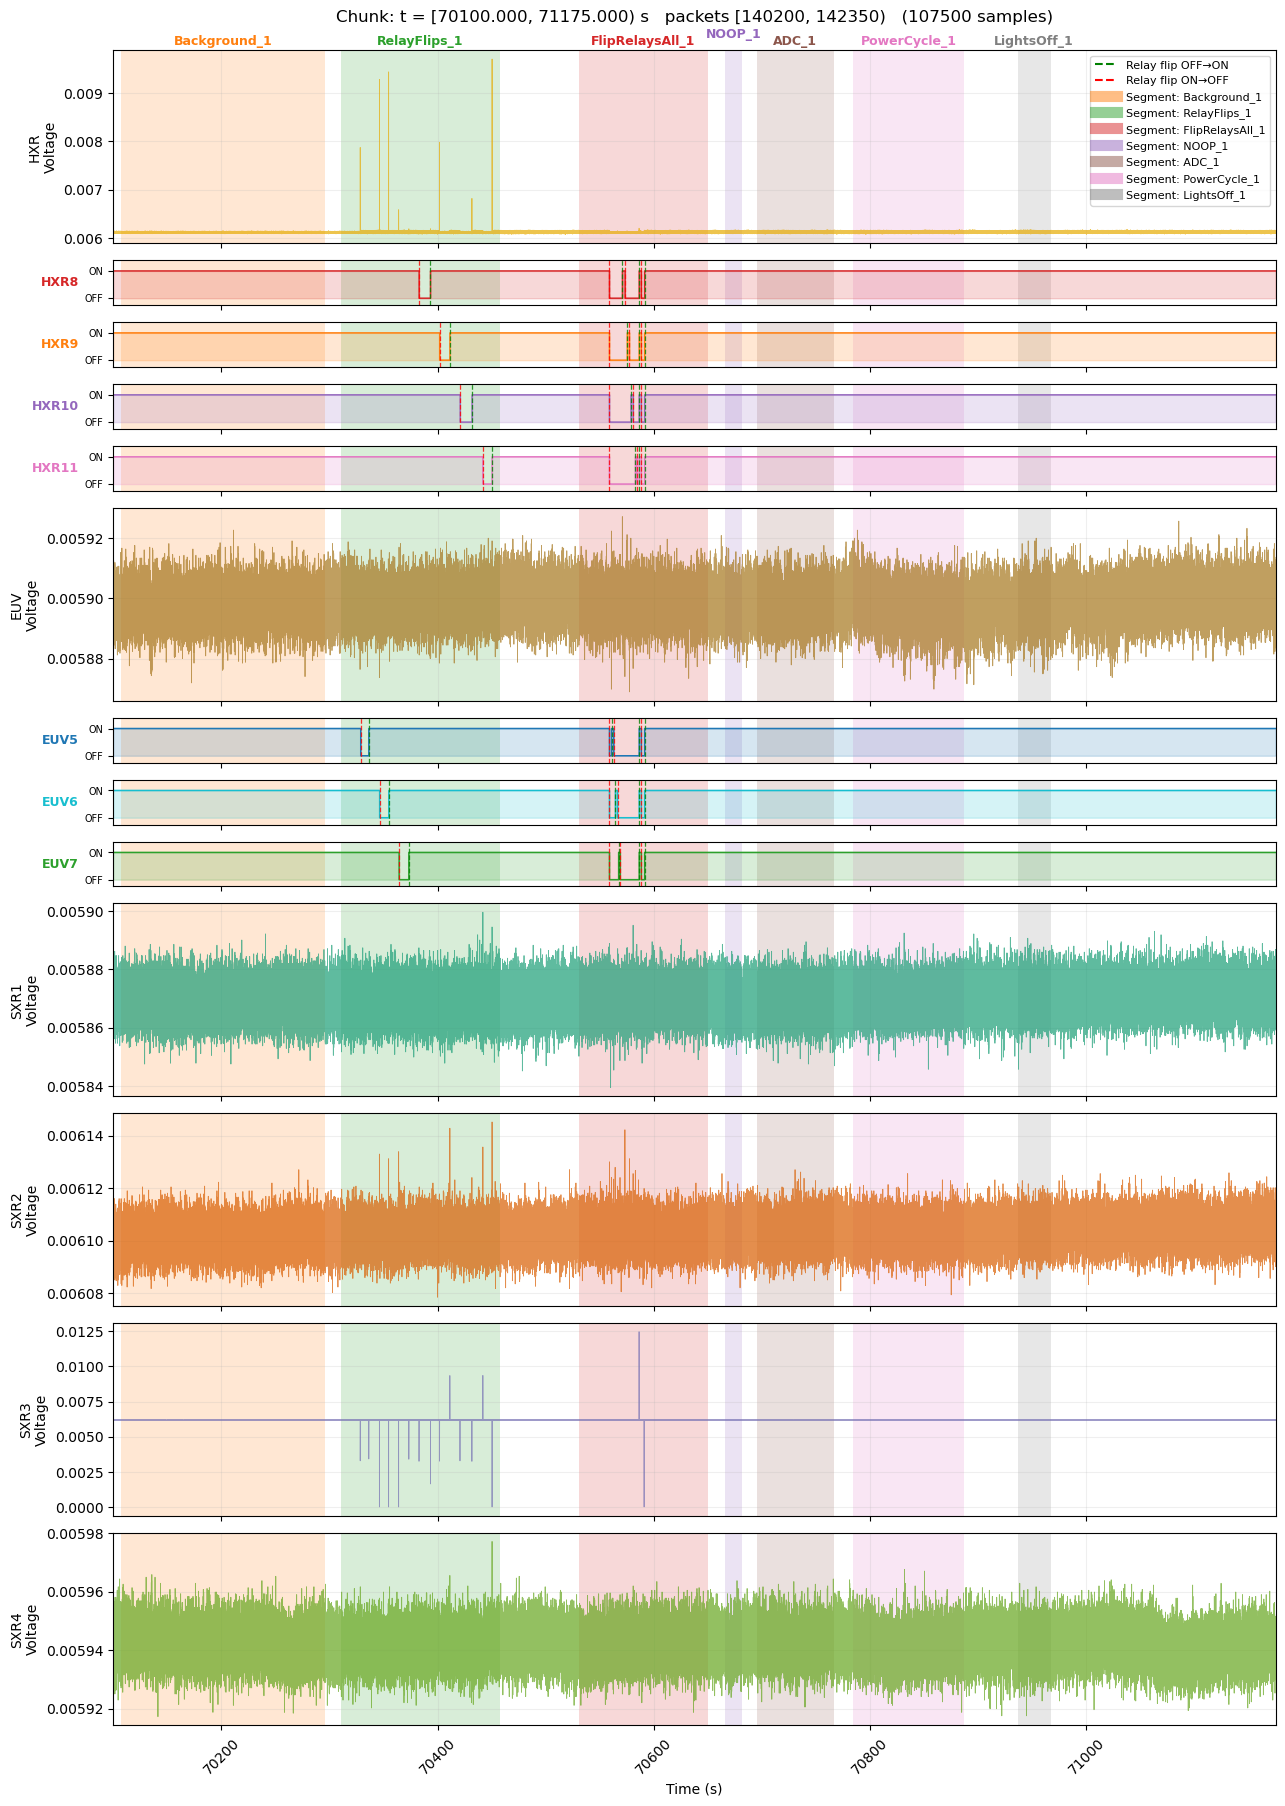

In [145]:
_SEGMENT_PALETTE = plt.get_cmap('tab10')

def plot_chunk(t0, t1):
    """Plot ADC channels + relay states for the time window [t0, t1) seconds.

    Any detected segments (from the .rpt auto-selection cell) whose time range
    intersects [t0, t1) are overlaid as translucent axvspans in distinct colors
    and labeled by name above the first channel panel. Labels are staggered
    onto multiple rows when needed so they don't overlap each other or the
    title.

    Visualization-only: does NOT modify SEGMENT_START_PACKET/END_PACKET, the
    `segment` dict, or any downstream analysis. Time axis is absolute seconds
    so values read off the overview plot above plug straight in.
    """
    n_pkts_total  = len(packetList)
    n_samp_total  = n_pkts_total * N_SEGMENTS
    total_seconds = n_samp_total * DT

    if t1 <= t0:
        print(f"plot_chunk: t1 ({t1}) must be > t0 ({t0}).")
        return

    # Seconds -> sample -> packet, clamped to the capture.
    s0 = max(0, int(round(t0 / DT)))
    s1 = min(n_samp_total, int(round(t1 / DT)))
    start_pkt = max(0, s0 // N_SEGMENTS)
    end_pkt   = min(n_pkts_total, -(-s1 // N_SEGMENTS))  # ceil-div
    if end_pkt <= start_pkt:
        end_pkt = min(n_pkts_total, start_pkt + 1)

    clamped = (t0 < 0) or (t1 > total_seconds)
    if clamped:
        print(f"plot_chunk: range clamped to [0, {total_seconds:.2f}) s "
              f"(requested [{t0}, {t1}) s).")

    chunk = selectSegment(data, start_pkt, end_pkt)
    s_lo  = start_pkt * N_SEGMENTS
    n_samp = len(chunk['SXR1'])
    x_time = (s_lo + np.arange(n_samp)) * DT

    # Visible window for segment-intersection tests.
    win_lo = x_time[0]
    win_hi = x_time[-1] + DT
    win_span = max(win_hi - win_lo, 1e-9)

    # Resolve all detected segments (set by the auto-selection cell) and keep
    # only those that overlap the visible window. Each gets a distinct color
    # by its original index in `available` so colors stay stable across chunks.
    try:
        _available = available
    except NameError:
        _available = []
    visible_segments = []
    for i, s in enumerate(_available):
        seg_t0 = s["start_pkt"] * SAMPLES_PER_PACKET * DT
        seg_t1 = s["end_pkt"]   * SAMPLES_PER_PACKET * DT
        if seg_t1 > win_lo and seg_t0 < win_hi:
            visible_segments.append({
                "label": s["label"],
                "t0":    seg_t0,
                "t1":    seg_t1,
                "color": _SEGMENT_PALETTE(i % 10),
            })

    # ----- Assign each label to a vertical row to avoid overlaps -----
    # We approximate each label's screen width as a fraction of the x-axis: a
    # character is ~7 px at fontsize 9, divided by an assumed figure width in
    # px to get an axes-fraction width. We then place labels left-to-right and
    # bump to the next row whenever the next label's left edge collides with
    # the rightmost label already on that row.
    APPROX_CHAR_FRAC = 7.0 / (15 * 72)   # ~chars wide in axes fraction at 72 dpi
    PAD_FRAC         = 0.01              # min gap between labels in axes fraction

    sorted_segs = sorted(enumerate(visible_segments),
                         key=lambda kv: max(kv[1]["t0"], win_lo))
    row_right_edge = []   # rightmost occupied x (axes fraction) per row
    label_rows = [0] * len(visible_segments)
    for orig_i, seg in sorted_segs:
        vis_lo = max(seg["t0"], win_lo)
        vis_hi = min(seg["t1"], win_hi)
        cx_frac = (0.5 * (vis_lo + vis_hi) - win_lo) / win_span
        half_w  = 0.5 * len(seg["label"]) * APPROX_CHAR_FRAC
        left    = cx_frac - half_w
        right   = cx_frac + half_w
        placed = False
        for row, r_edge in enumerate(row_right_edge):
            if left >= r_edge + PAD_FRAC:
                label_rows[orig_i] = row
                row_right_edge[row] = right
                placed = True
                break
        if not placed:
            label_rows[orig_i] = len(row_right_edge)
            row_right_edge.append(right)
    n_label_rows = max(len(row_right_edge), 1)

    # Same row layout as the overview plot.
    rows = []
    for ch in CHANNEL_ORDER:
        rows.append(('channel', ch))
        for relay in CHANNEL_RELAYS[ch]:
            rows.append(('relay', relay))
    height_ratios = [3.0 if kind == 'channel' else 0.7 for kind, _ in rows]

    fig, axes = plt.subplots(
        len(rows), 1,
        figsize=(15, 0.95 * sum(height_ratios)),
        sharex=True,
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.15},
    )

    # Title sits above whatever stack of segment labels we end up with.
    LABEL_ROW_HEIGHT = 0.035     # axes fraction per label row
    LABEL_BASE_Y     = 1.015
    title_y = LABEL_BASE_Y + n_label_rows * LABEL_ROW_HEIGHT + 0.02
    axes[0].set_title(
        f"Chunk: t = [{win_lo:.3f}, {win_hi:.3f}) s   "
        f"packets [{start_pkt}, {end_pkt})   ({n_samp} samples)",
        fontsize=12,
        y=title_y,
    )

    for ax, (kind, name) in zip(axes, rows):
        if kind == 'channel':
            ax.plot(x_time, chunk[name].astype(float),
                    linewidth=0.6, color=CHANNEL_COLORS[name], alpha=0.7)
            ax.set_ylabel(f'{name}\nVoltage', fontsize=10)
            ax.tick_params(axis='x', labelrotation=45)
            ax.grid(True, alpha=0.2)
        else:
            color    = RELAY_COLORS[name]
            expanded = np.repeat(chunk['relayStates'][name],
                                 SAMPLES_PER_PACKET).astype(float)
            x_rel    = (s_lo + np.arange(len(expanded))) * DT
            ax.plot(x_rel, expanded, linewidth=1.1, color=color,
                    drawstyle='steps-post')
            ax.fill_between(x_rel, expanded, step='post', color=color, alpha=0.18)
            ax.set_ylabel(name, color=color, fontweight='bold', fontsize=9,
                          rotation=0, ha='right', va='center')
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['OFF', 'ON'], fontsize=7)
            ax.set_ylim(-0.25, 1.4)

            # Flip packet indices were re-zeroed by selectSegment; un-shift to absolute.
            for f in chunk['relayFlips'][name]:
                pos = (f['packet'] + start_pkt) * SAMPLES_PER_PACKET * DT
                fc  = 'green' if f['direction'].endswith('ON') else 'red'
                ax.axvline(pos, color=fc, linestyle='--', linewidth=0.9, alpha=0.8)

        # Overlay any segments that intersect this chunk's window. axvspan
        # auto-clips to the axes' xlim, so out-of-window edges render cleanly.
        for seg in visible_segments:
            ax.axvspan(seg["t0"], seg["t1"],
                       color=seg["color"], alpha=0.18, linewidth=0, zorder=0)

    # Clamp x-axis so we don't pad to off-window axvspan edges.
    axes[0].set_xlim(win_lo, win_hi)

    # Segment name labels above the first channel panel, x in data coords and
    # y in axes fraction so collisions are computed in screen-ish space.
    top_ax    = axes[0]
    label_trf = top_ax.get_xaxis_transform()
    for i, seg in enumerate(visible_segments):
        vis_lo = max(seg["t0"], win_lo)
        vis_hi = min(seg["t1"], win_hi)
        cx     = 0.5 * (vis_lo + vis_hi)
        y_frac = LABEL_BASE_Y + label_rows[i] * LABEL_ROW_HEIGHT
        top_ax.text(
            cx, y_frac, seg["label"],
            transform=label_trf,
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=seg["color"], clip_on=False,
        )

    axes[-1].set_xlabel('Time (s)', fontsize=10)

    legend_elements = [
        Line2D([0], [0], color='green', linestyle='--', label='Relay flip OFF→ON'),
        Line2D([0], [0], color='red',   linestyle='--', label='Relay flip ON→OFF'),
    ]
    for seg in visible_segments:
        legend_elements.append(
            Line2D([0], [0], color=seg["color"], linewidth=8, alpha=0.5,
                   label=f"Segment: {seg['label']}")
        )
    axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()


# Example — edit t0, t1 and re-run this cell:
plot_chunk(t0=70100.0, t1=(len(data['SXR1']) * 0.01))

In [146]:
print(f"{np.std(data['SXR3']):3f}")

0.000009


In [147]:
#  Raw current statistics table 
TRANSIMPEDANCE = {  
    'SXR1': 112e6, 'SXR2': 112e6, 'SXR3': 112e6, 'SXR4': 112e6,
    'HXR':  9e6,   'EUV':  7.8e6,
}

def _voltage_stats_row(name, v):
    """[name, mean_V, rms_V, std_V, skew, kurt] for one channel."""
    return [
        name,
        float(np.mean(v)),
        float(np.sqrt(np.mean(v ** 2))),
        float(np.std(v)),
        float(skew(v, bias=True)),
        float(kurtosis(v, bias=True, fisher=True)),
    ]

def _to_current_fA(rows):
    scaled = []
    for name, mean_v, rms_v, std_v, sk, kt in rows:
        s = 1e15 / TRANSIMPEDANCE[name]
        scaled.append([name, mean_v * s, rms_v * s, std_v * s, sk, kt])
    return scaled

raw_stats_v   = [_voltage_stats_row(name, channels[name])
                 for name in CHANNEL_NAMES_REPORT_ORDER]
raw_stats_fA  = _to_current_fA(raw_stats_v)

raw_stats_table = Table(
    rows=raw_stats_v,
    names=('Channel', 'Mean (fA)', 'RMS (fA)', 'Std Dev (fA)', 'Skew', 'Kurtosis'),
)
for col in ('Mean (fA)', 'RMS (fA)', 'Std Dev (fA)'):
    raw_stats_table[col].format = '.3f'
for col in ('Skew', 'Kurtosis'):
    raw_stats_table[col].format = '.4f'

print('Raw Current Statistics')
raw_stats_table.pprint_all()

Raw Current Statistics
Channel Mean (fA) RMS (fA) Std Dev (fA)    Skew     Kurtosis 
------- --------- -------- ------------ --------- -----------
   SXR1     0.006    0.006        0.000   -0.4416      1.2856
   SXR2     0.006    0.006        0.000   -0.1771      0.4580
   SXR3     0.006    0.006        0.000 -236.5519 213688.4709
   SXR4     0.006    0.006        0.000   -0.7432      2.7274
    HXR     0.006    0.006        0.000    3.4939    573.7266
    EUV     0.006    0.006        0.000   -0.5892      1.8332


# Analysis

## Detrending (Savitzky–Golay)

In [148]:
# Detrend each channel by subtracting a Savitzky-Golay trend 
SAVGOL_WINDOW    = 51
SAVGOL_POLYORDER = 3
SAVGOL_PASSES    = 2

def detrend_savgol(signal, window_length=SAVGOL_WINDOW,
                   polyorder=SAVGOL_POLYORDER, num_passes=SAVGOL_PASSES):
    trend = signal.copy()
    for _ in range(num_passes):
        trend = savgol_filter(trend, window_length=window_length, polyorder=polyorder)
    return signal - trend, trend

detrended = {}
trends    = {}
for name in CHANNEL_NAMES_REPORT_ORDER:
    detrended[name], trends[name] = detrend_savgol(channels[name])
    print(f"{name:4s}  detrended std: {detrended[name].std():.3f}   "
          f"trend range: [{trends[name].min():.1f}, {trends[name].max():.1f}]")

SXR1  detrended std: 0.000   trend range: [0.0, 0.0]
SXR2  detrended std: 0.000   trend range: [0.0, 0.0]
SXR3  detrended std: 0.000   trend range: [0.0, 0.0]
SXR4  detrended std: 0.000   trend range: [0.0, 0.0]
HXR   detrended std: 0.000   trend range: [0.0, 0.0]
EUV   detrended std: 0.000   trend range: [0.0, 0.0]


## Room EMI removal (40 Hz notch via FFT)

In [149]:
# Remove the room's 40 Hz EMI spike from each detrended channel 
EMI_CENTER_HZ   = 40.1
EMI_HALFWIDTH   = 0.2

def remove_room_emi(signal, sampling_rate=SAMPLING_RATE,
                    center_hz=EMI_CENTER_HZ, halfwidth_hz=EMI_HALFWIDTH):
    n = len(signal)
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1.0 / sampling_rate))
    data = signal - np.mean(signal)

    freq_shifted = np.fft.fftshift(np.fft.fft(data))

    pos_band = (f >= center_hz - halfwidth_hz) & (f <= center_hz + halfwidth_hz)
    neg_band = (f >= -center_hz - halfwidth_hz) & (f <= -center_hz + halfwidth_hz)
    freq_shifted[pos_band] = 0
    freq_shifted[neg_band] = 0

    cleaned = np.real(np.fft.ifft(np.fft.ifftshift(freq_shifted)))
    return cleaned

cleaned = {}
rms_report = []
for name in CHANNEL_NAMES_REPORT_ORDER:
    cleaned[name] = remove_room_emi(detrended[name])
    rms_before = np.sqrt(np.mean((detrended[name] - detrended[name].mean()) ** 2))
    rms_after  = np.sqrt(np.mean(cleaned[name] ** 2))
    rms_report.append((name, rms_before, rms_after))
    print(f"{name:4s}  RMS before EMI removal: {rms_before:.4f}   "
          f"after: {rms_after:.4f}   delta: {rms_before - rms_after:+.4f}")

SXR1  RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000
SXR2  RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000
SXR3  RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000
SXR4  RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000
HXR   RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000
EUV   RMS before EMI removal: 0.0000   after: 0.0000   delta: +0.0000


## Display EMI-filtered and detrended voltages

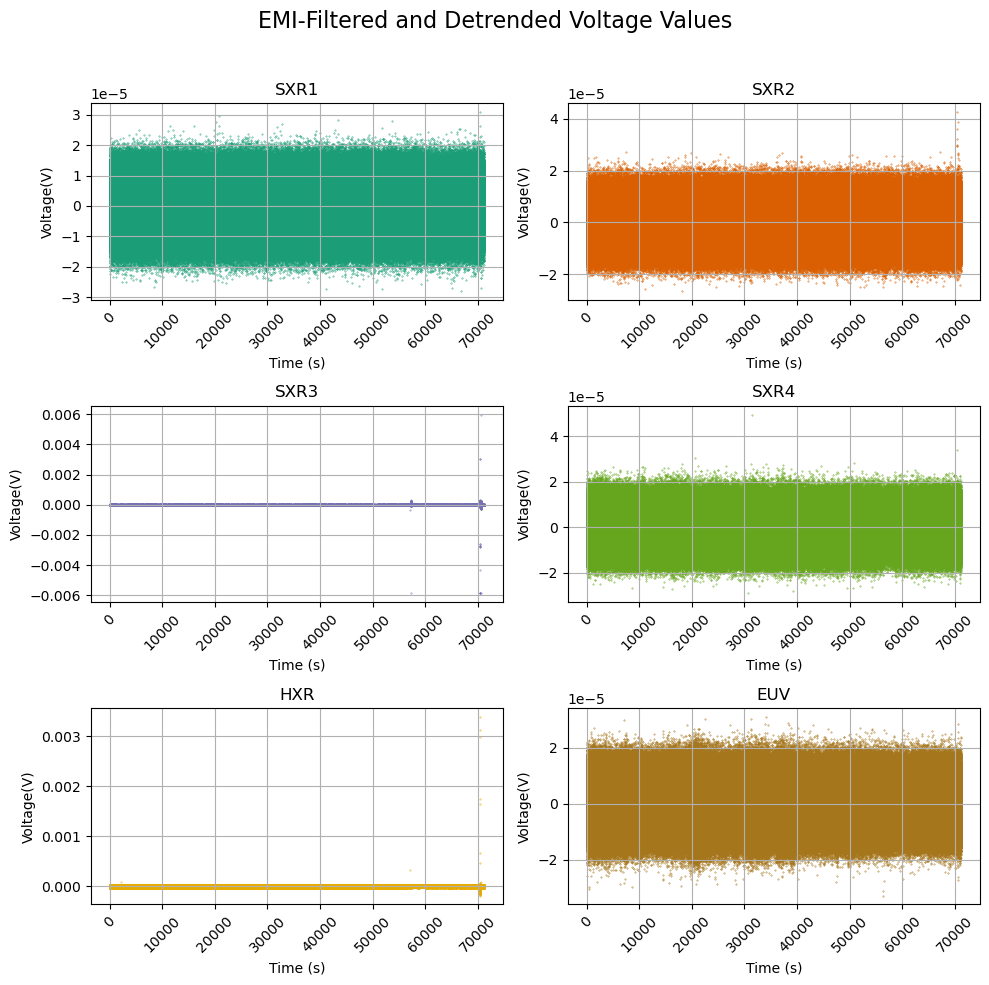

In [150]:
n_samples_cleaned = len(cleaned['SXR1'])
time_cleaned      = np.arange(n_samples_cleaned) * DT

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes = axes.ravel()

for i, name in enumerate(CHANNEL_NAMES_REPORT_ORDER):
    ax = axes[i]
    ax.scatter(time_cleaned, cleaned[name],
               color=CHANNEL_COLORS[name], s=0.1)
    ax.set_title(name)
    ax.set_ylabel('Voltage(V)')
    ax.set_xlabel('Time (s)')
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(True)

fig.suptitle('EMI-Filtered and Detrended Voltage Values', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [151]:
# Detrended + EMI-filtered current statistics table 
det_stats_v  = [_voltage_stats_row(name, cleaned[name])
                for name in CHANNEL_NAMES_REPORT_ORDER]
det_stats_fA = _to_current_fA(det_stats_v)

det_stats_table = Table(
    rows=det_stats_fA,
    names=('Channel', 'Mean (fA)', 'RMS (fA)', 'Std Dev (fA)', 'Skew', 'Kurtosis'),
)
for col in ('Mean (fA)', 'RMS (fA)', 'Std Dev (fA)'):
    det_stats_table[col].format = '.3f'
for col in ('Skew', 'Kurtosis'):
    det_stats_table[col].format = '.4f'

print('Detrended + EMI-Filtered Current Statistics')
det_stats_table.pprint_all()

Detrended + EMI-Filtered Current Statistics
Channel Mean (fA) RMS (fA) Std Dev (fA)    Skew     Kurtosis 
------- --------- -------- ------------ --------- -----------
   SXR1     0.000   50.111       50.111    0.0054     -0.1494
   SXR2    -0.000   48.014       48.014    0.0256      0.0080
   SXR3     0.000   77.312       77.312 -249.2994 229714.1329
   SXR4     0.000   48.121       48.121    0.0463      0.0411
    HXR    -0.000  856.030      856.030   32.6833  12950.5214
    EUV    -0.000  721.507      721.507    0.0486     -0.0160
